# Data Loading

In [1]:
import matplotlib.pyplot as plt
import os
import zipfile
try:
    import gdown
except ImportError:
    !pip install gdown

def download_dataset_from_google_drive(google_file_id: str, output_file_name: str, quiet_download: bool) -> str:
    file_path = f'./{output_file_name}'

    if not os.path.exists(file_path):
        gdown.download(id=google_file_id, output=output_file_name, quiet=quiet_download)
    else:
        print(f"{output_file_name} already exists!")
    if os.path.exists(file_path):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall('./')
    return file_path

In [2]:
#https://drive.google.com/file/d/1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh/view?usp=sharing
data_path = "1ke6APNDoRqSCSoaHbncT_WpmSNCT9sbh"

In [3]:
data_dir = download_dataset_from_google_drive(data_path, "data.zip", True)

In [4]:
import os
import numpy as np
import random

def read_text_files(folder_path):
    """Reads all text files in the given folder."""
    contents = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        # Check if it's a file and has .txt extension
        if os.path.isfile(file_path) and filename.endswith(".txt"):
            with open(file_path, "r") as file:
                content = file.read()
                contents.append(content)
    return contents

In [5]:
# Training set
train_positive_reviews = read_text_files("aclImdb/train/pos/")
train_negative_reviews = read_text_files("aclImdb/train/neg/")
train_reviews = train_positive_reviews + train_negative_reviews
y_train = np.array([1]*12500 + [0]*12500)
#Test set
test_positive_reviews = read_text_files("aclImdb/test/pos/")
test_negative_reviews = read_text_files("aclImdb/test/neg/")
test_reviews = test_positive_reviews + test_negative_reviews
y_test = np.array([1]*12500 + [0]*12500)


# Data Processing

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [7]:
vocabulary = 10000
tokenizer = Tokenizer(num_words = vocabulary)

In [8]:
tokenizer.fit_on_texts(train_reviews)

In [9]:
word_index = tokenizer.word_index

In [10]:
sequences_train = tokenizer.texts_to_sequences(train_reviews)

In [11]:
word_num = 500
x_train = pad_sequences(sequences_train, maxlen = word_num)

## Split Training and Validation Data and Process Test Data

In [12]:
n = x_train.shape[0]
np.random.seed(42)
rand_perm = np.random.permutation(n)
n_valid = int(n * 0.2)
labels_train = np.array(y_train)
x_valid = x_train[rand_perm[0:n_valid], :]
y_valid = labels_train[rand_perm[0:n_valid]]
x_train = x_train[rand_perm[n_valid:n], :]
y_train = labels_train[rand_perm[n_valid:n]]

In [13]:
word_index = tokenizer.word_index
sequences_test = tokenizer.texts_to_sequences(test_reviews)
word_num = 500
x_test = pad_sequences(sequences_test, maxlen=word_num)

# Build a RNN model

In [14]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Embedding, Dense, Input

vocabulary = 10000
embedding_dim = 32
word_num = 500
state_dim = 32

model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(SimpleRNN(state_dim, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from keras import optimizers

epochs = 3

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss = "binary_crossentropy", metrics = ['acc'])

In [16]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - acc: 0.6546 - loss: 0.5975 - val_acc: 0.8284 - val_loss: 0.4025
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - acc: 0.8526 - loss: 0.3527 - val_acc: 0.8250 - val_loss: 0.3904
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - acc: 0.8968 - loss: 0.2659 - val_acc: 0.8612 - val_loss: 0.3528


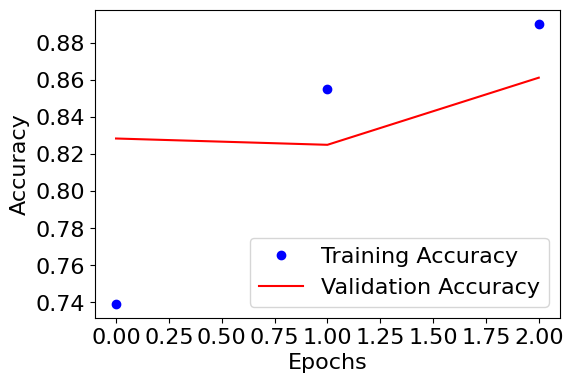

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_acc = history.history['acc']
valid_acc = history.history['val_acc']
plt.plot(epochs_list, train_acc, 'bo', label='Training Accuracy')
plt.plot(epochs_list, valid_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

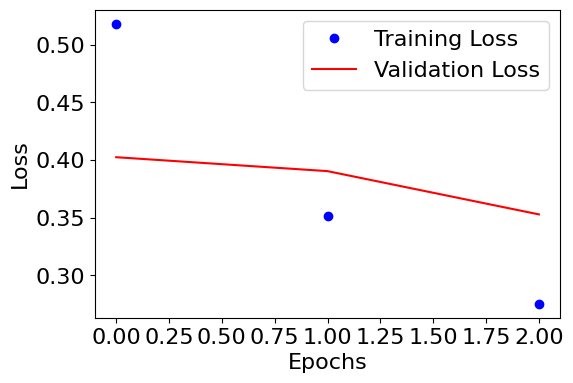

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4))
epochs_list = range(epochs)
train_loss = history.history['loss']
valid_loss = history.history['val_loss']
plt.plot(epochs_list, train_loss, 'bo', label='Training Loss')
plt.plot(epochs_list, valid_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

In [19]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - acc: 0.8913 - loss: 0.2904
loss = 0.36016786098480225
acc = 0.8578799962997437


# Build an LSTM model

In [20]:
from keras.models import Sequential
from keras.layers import LSTM, Embedding, Dense, Input

vocabulary = 10000
embedding_dim = 32
word_num = 500
state_dim = 32

model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(LSTM(state_dim, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from keras import optimizers

epochs = 10

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001),
              loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=epochs,
                    batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - acc: 0.5348 - loss: 0.6924 - val_acc: 0.6306 - val_loss: 0.6871
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - acc: 0.6790 - loss: 0.6497 - val_acc: 0.7948 - val_loss: 0.5033
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - acc: 0.8121 - loss: 0.4636 - val_acc: 0.8418 - val_loss: 0.3936
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.8669 - loss: 0.3455 - val_acc: 0.8706 - val_loss: 0.3276
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - acc: 0.8943 - loss: 0.2856 - val_acc: 0.8822 - val_loss: 0.3043
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - acc: 0.9052 - loss: 0.2545 - val_acc: 0.8852 - val_loss: 0.2894
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - acc: 0.9176 - loss: 0.2239 - val_acc: 0.8888 - val_loss: 0.2834
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - acc: 0.9235 - loss: 0.2082 - val_acc: 0.8906 - val_loss: 0.2794
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

In [22]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8768 - loss: 0.3178
loss = 0.29477977752685547
acc = 0.8847200274467468


In [23]:
#Adding dropout

In [24]:
model = Sequential()
model.add(Input((word_num, )))
model.add(Embedding(vocabulary, embedding_dim))
model.add(LSTM(state_dim, return_sequences=False, dropout = 0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
epochs = 10

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001),
              loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=epochs,
                    batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - acc: 0.5234 - loss: 0.6927 - val_acc: 0.5820 - val_loss: 0.6904
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - acc: 0.6213 - loss: 0.6802 - val_acc: 0.7328 - val_loss: 0.5605
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - acc: 0.7718 - loss: 0.5125 - val_acc: 0.8326 - val_loss: 0.4090
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - acc: 0.8454 - loss: 0.3729 - val_acc: 0.8526 - val_loss: 0.3627
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - acc: 0.8838 - loss: 0.3003 - val_acc: 0.8712 - val_loss: 0.3159
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - acc: 0.8941 - loss: 0.2754 - val_acc: 0.8750 - val_loss: 0.3027
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - acc: 0.9106 - loss: 0.2389 - val_acc: 0.8798 - val_loss: 0.2922
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - acc: 0.9151 - loss: 0.2253 - val_acc: 0.8866 - val_loss: 0.2945
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

In [26]:
loss_and_acc = model.evaluate(x_test, y_test)
print('loss = ' + str(loss_and_acc[0]))
print('acc = ' + str(loss_and_acc[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8892 - loss: 0.2776
loss = 0.2929030954837799
acc = 0.880840003490448
